In [2]:
import random
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt

from pathlib import Path
from impisc.impisc.et_daqbox import daq_box_api as dba

In [3]:
threshold_path = Path('calibration/threshold')
thresh_wf = Path('calibration/threshold/wf')

#### Function

In [4]:
def spec_parse(fn, PACKET_SIZE):
    spectra = []

    with open(fn, "rb") as f:
        while True:
            data = f.read(PACKET_SIZE)
            if len(data) == 0:
                # Hit end of file
                break
            spectra.append(dba.parse_spectrum_packet(data))
        
    return np.array(spectra)

def wf_parse(fn, PACKET_SIZE):
    waveforms = []

    with open(fn, "rb") as f:
        while True:
            data = f.read(PACKET_SIZE)
            if len(data) == 0:
                # Hit end of file
                break
            waveforms.append(dba.parse_waveform_packet(data))
    return waveforms

### Analyses

In [5]:
spec_files = sorted(threshold_path.glob('*.bin'))
spec_files

[PosixPath('calibration/threshold/t10_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t20_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t30_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t40_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t50_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t60_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t70_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t80_39V_lyso_z6.bin'),
 PosixPath('calibration/threshold/t90_39V_lyso_z6.bin')]

In [6]:
PACKET_SIZE = 8000
types=['39V t10 LYSO', '39V t20 LYSO', '39V t30 LYSO', '39V t40 LYSO', '39V t50 LYSO', '39V t60 LYSO', '39V t70 LYSO', '39V t80 LYSO', '39V t90 LYSO', '39V t100 LYSO']
spectra_ = []

for fn in spec_files:
    spectra = spec_parse(fn, PACKET_SIZE)
    spectra_.append(spectra)

print(spectra.shape)
print('There are spectra for', len(spectra_), 'spectra types')

(1920, 4, 1000)
There are spectra for 9 spectra types


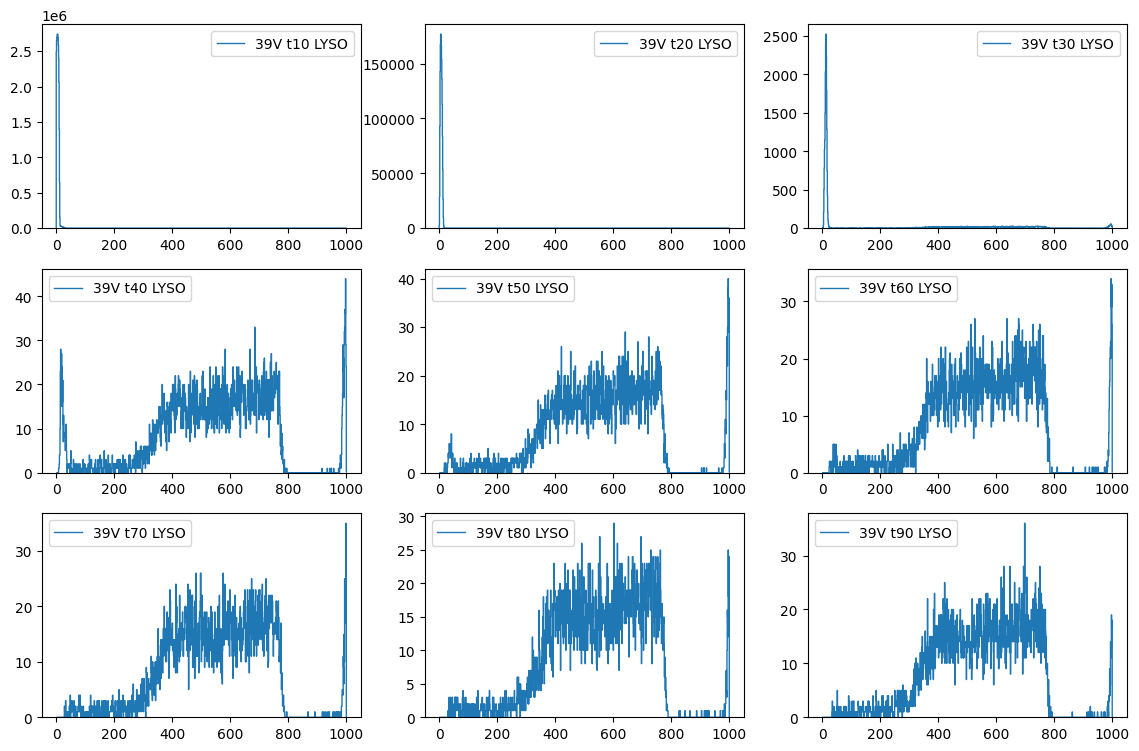

In [7]:
fig, ax = plt.subplots(3,3, figsize=(14,9))
bins = np.arange(1001)
total_counts = []

for i, axis in enumerate(ax.flatten()):

    summation = spectra_[i].sum(axis=0)[3]
    total_counts.append(summation.sum())

    axis.stairs(summation, bins, label=f'{types[i]}')
    axis.legend()

In [8]:

tg100_path = threshold_path / 't_greaterthan_100'
spec_files_tg100 = sorted(tg100_path.glob('*.bin'))

In [9]:
PACKET_SIZE = 8000
types=['39V t100 LYSO', '39V t110 LYSO', '39V t120 LYSO', '39V t130 LYSO', '39V t140 LYSO', '39V t150 LYSO', '39V t160 LYSO', '39V t170 LYSO', '39V t180 LYSO', '39V t190 LYSO', '39V t200 LYSO']
spectra__ = []

for fn in spec_files_tg100:
    spectra = spec_parse(fn, PACKET_SIZE)
    spectra__.append(spectra)

print(spectra.shape)
print('There are spectra for', len(spectra__), 'spectra types')

(1920, 4, 1000)
There are spectra for 11 spectra types


IndexError: list index out of range

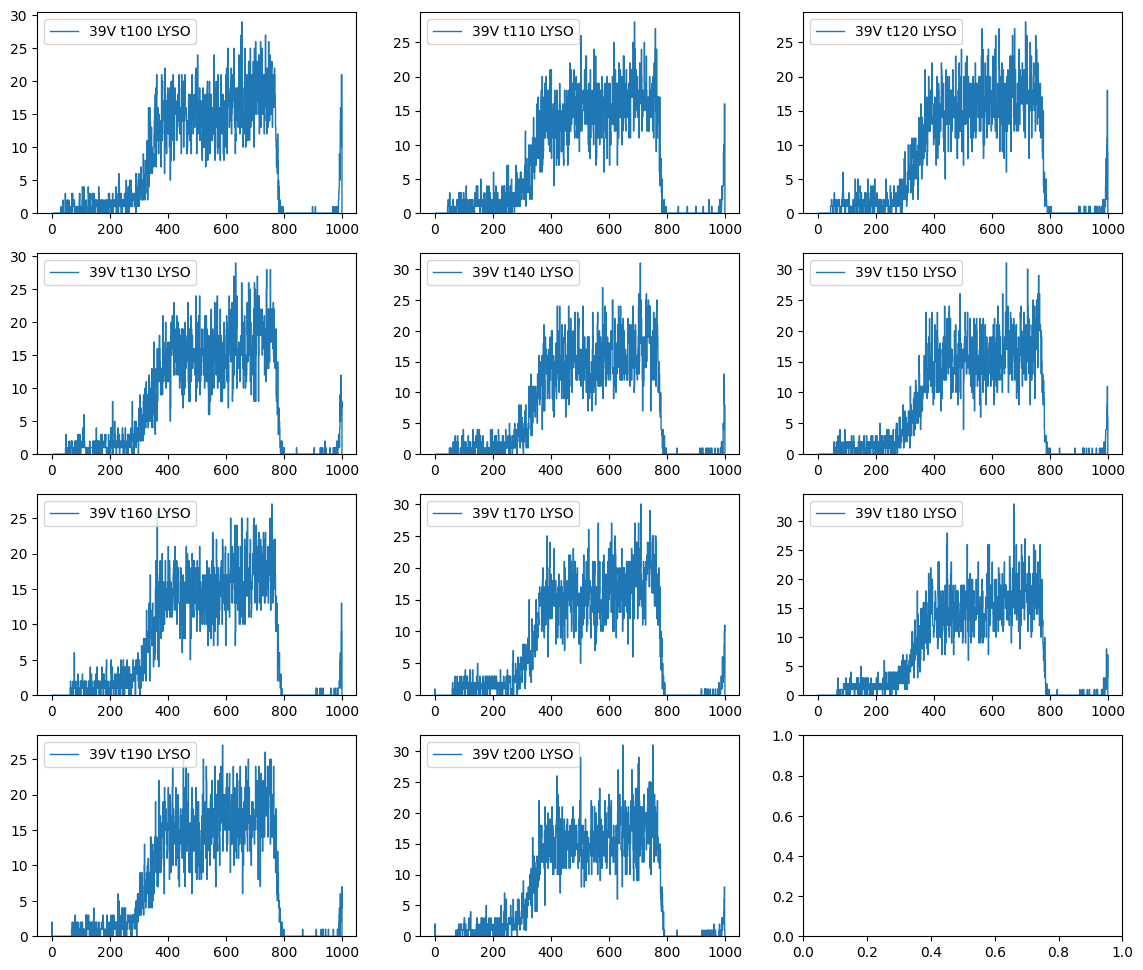

In [10]:
fig, ax = plt.subplots(4,3, figsize=(14,12))
bins = np.arange(1001)
total_counts_ = []

for i, axis in enumerate(ax.flatten()):

    summation = spectra__[i].sum(axis=0)[3]
    total_counts_.append(summation.sum())

    axis.stairs(summation, bins, label=f'{types[i]}')
    axis.legend()

In [11]:
total_counts + total_counts_

[np.int64(28286468),
 np.int64(1543154),
 np.int64(26900),
 np.int64(8220),
 np.int64(7669),
 np.int64(7551),
 np.int64(7486),
 np.int64(7564),
 np.int64(7462),
 np.int64(7653),
 np.int64(7341),
 np.int64(7581),
 np.int64(7452),
 np.int64(7400),
 np.int64(7549),
 np.int64(7399),
 np.int64(7732),
 np.int64(7445),
 np.int64(7546),
 np.int64(7591)]

In [12]:
count = total_counts + total_counts_
count

[np.int64(28286468),
 np.int64(1543154),
 np.int64(26900),
 np.int64(8220),
 np.int64(7669),
 np.int64(7551),
 np.int64(7486),
 np.int64(7564),
 np.int64(7462),
 np.int64(7653),
 np.int64(7341),
 np.int64(7581),
 np.int64(7452),
 np.int64(7400),
 np.int64(7549),
 np.int64(7399),
 np.int64(7732),
 np.int64(7445),
 np.int64(7546),
 np.int64(7591)]

Text(0.5, 1.0, 'LYSO trapezoid background without source')

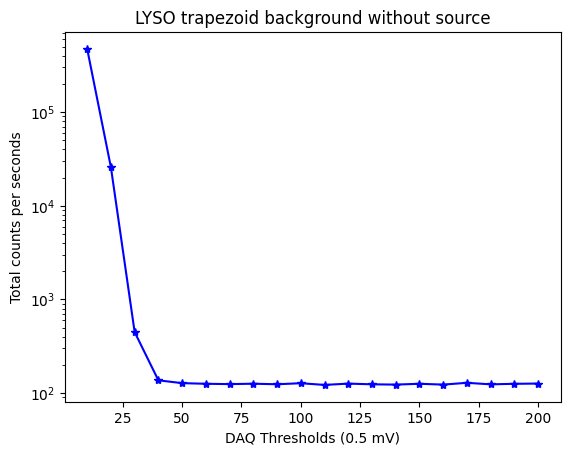

In [13]:
thresholds = np.arange(10, 210, 10)

plt.plot(thresholds, [counts/60 for counts in count], color='blue', marker='*')
plt.yscale('log')
plt.ylabel('Total counts per seconds')
plt.xlabel('DAQ Thresholds (0.5 mV)')
plt.title('LYSO trapezoid background without source')

Text(0.5, 1.0, 'LYSO trapezoid background without source')

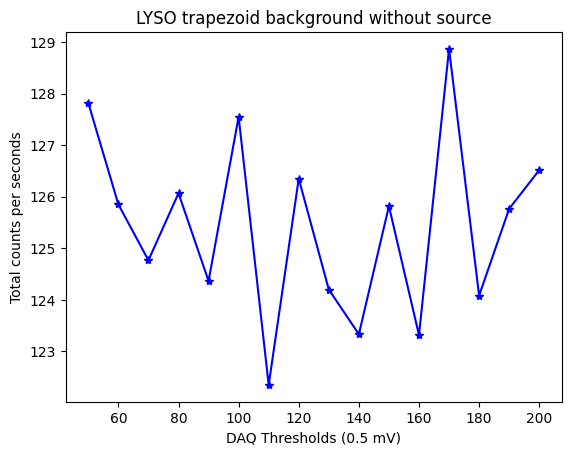

In [14]:
thresholds_ = thresholds[4:]
count_ = count[4:]
plt.plot(thresholds_, [counts/60 for counts in count_], color='blue', marker='*')
plt.yscale('linear')
plt.ylabel('Total counts per seconds')
plt.xlabel('DAQ Thresholds (0.5 mV)')
plt.title('LYSO trapezoid background without source')

In [29]:
a = count[4:]
b = [i/60 for i in a]
np.mean(b)

np.float64(125.43854166666667)

### Waveforms

In [ ]:
wff = sorted(thresh_wf.glob('*.bin'))
print(wff)

[PosixPath('calibration/threshold/wf/wf_am241.bin'), PosixPath('calibration/threshold/wf/wf_t10.bin')]


In [ ]:
PACKET_SIZE = 8000
waveforms_ = []

for fn in wff:
    waveforms = wf_parse(fn, PACKET_SIZE)
    waveforms_.append(waveforms)

print(len(waveforms))

9000


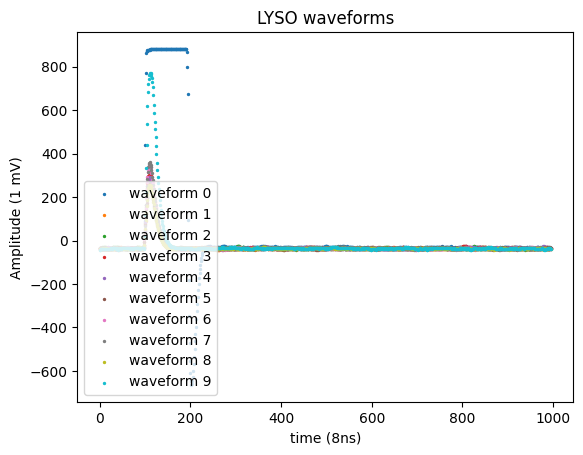

In [ ]:
selection = random.choices(waveforms_[0], k=10) # choose wf
t = np.arange(len(selection[0]['data']))
waveform = np.array(selection[0]['data'])

fig, ax = plt.subplots()
for i, s in enumerate(selection):
    ax.scatter(t, s['data'], 2, label=f'waveform {i}')
    # ax.set_xlim(80, 250)
    # ax.set_ylim(-20,100)
    plt.legend()
ax.set_xlabel('time (8ns)')
ax.set_ylabel('Amplitude (1 mV)')
plt.title('LYSO waveforms')
plt.show()